[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AyhamAlsuwi/ML-projects/blob/main/Fraud-job-application-detection-model/Real%20-%20Fake%20Job%20Posting%20.ipynb)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

In [5]:
df  = pd.read_csv('fake_job_postings.csv')

In [6]:
df.shape

(17880, 18)

In [7]:
df

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17875,17876,Account Director - Distribution,"CA, ON, Toronto",Sales,NaN,Vend is looking for some awesome new talent to...,Just in case this is the first time you’ve vis...,To ace this role you:Will eat comprehensive St...,What can you expect from us?We have an open cu...,0,1,1,Full-time,Mid-Senior level,NaN,Computer Software,Sales,0
17876,17877,Payroll Accountant,"US, PA, Philadelphia",Accounting,NaN,WebLinc is the e-commerce platform and service...,The Payroll Accountant will focus primarily on...,- B.A. or B.S. in Accounting- Desire to have f...,Health &amp; WellnessMedical planPrescription ...,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Internet,Accounting/Auditing,0
17877,17878,Project Cost Control Staff Engineer - Cost Con...,"US, TX, Houston",NaN,NaN,We Provide Full Time Permanent Positions for m...,Experienced Project Cost Control Staff Enginee...,At least 12 years professional experience.Abil...,NaN,0,0,0,Full-time,NaN,NaN,NaN,NaN,0
17878,17879,Graphic Designer,"NG, LA, Lagos",NaN,NaN,NaN,Nemsia Studios is looking for an experienced v...,1. Must be fluent in the latest versions of Co...,Competitive salary (compensation will be based...,0,0,1,Contract,Not Applicable,Professional,Graphic Design,Design,0


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   job_id               17880 non-null  int64 
 1   title                17880 non-null  object
 2   location             17534 non-null  object
 3   department           6333 non-null   object
 4   salary_range         2868 non-null   object
 5   company_profile      14572 non-null  object
 6   description          17879 non-null  object
 7   requirements         15184 non-null  object
 8   benefits             10668 non-null  object
 9   telecommuting        17880 non-null  int64 
 10  has_company_logo     17880 non-null  int64 
 11  has_questions        17880 non-null  int64 
 12  employment_type      14409 non-null  object
 13  required_experience  10830 non-null  object
 14  required_education   9775 non-null   object
 15  industry             12977 non-null  object
 16  func

In [13]:
df.describe()

,job_id,telecommuting,has_company_logo,has_questions,fraudulent
count,17880.000000,17880.000000,17880.000000,17880.000000,17880.000000
mean,8940.500000,0.042897,0.795302,0.491723,0.048434
std,5161.655742,0.202631,0.403492,0.499945,0.214688
min,1.000000,0.000000,0.000000,0.000000,0.000000
25%,4470.750000,0.000000,1.000000,0.000000,0.000000
50%,8940.500000,0.000000,1.000000,0.000000,0.000000
75%,13410.250000,0.000000,1.000000,1.000000,0.000000
max,17880.000000,1.000000,1.000000,1.000000,1.000000


In [15]:
df.describe(include='O')

,title,location,department,salary_range,company_profile,description,requirements,benefits,employment_type,required_experience,required_education,industry,function
count,17880,17534,6333,2868,14572,17879,15184,10668,14409,10830,9775,12977,11425
unique,11231,3105,1337,874,1709,14801,11967,6204,5,7,13,131,37
top,English Teacher Abroad,"GB, LND, London",Sales,0-0,We help teachers get safe &amp; secure jobs ab...,"Play with kids, get paid for it Love travel? J...",University degree required. TEFL / TESOL / CEL...,See job description,Full-time,Mid-Senior level,Bachelor's Degree,Information Technology and Services,Information Technology
freq,311,718,551,142,726,379,410,726,11620,3809,5145,1734,1749


In [17]:
df.isna().sum()

job_id                     0
title                      0
location                 346
department             11547
salary_range           15012
company_profile         3308
description                1
requirements            2696
benefits                7212
telecommuting              0
has_company_logo           0
has_questions              0
employment_type         3471
required_experience     7050
required_education      8105
industry                4903
function                6455
fraudulent                 0
dtype: int64

In [19]:
df['fraudulent'].value_counts()

fraudulent
0    17014
1      866
Name: count, dtype: int64

In [21]:
df['industry'].value_counts()

industry
Information Technology and Services    1734
Computer Software                      1376
Internet                               1062
Marketing and Advertising               828
Education Management                    822
                                       ... 
Shipbuilding                              1
Sporting Goods                            1
Museums and Institutions                  1
Wine and Spirits                          1
Ranching                                  1
Name: count, Length: 131, dtype: int64

In [23]:
df['required_education'].value_counts()

required_education
Bachelor's Degree                    5145
High School or equivalent            2080
Unspecified                          1397
Master's Degree                       416
Associate Degree                      274
Certification                         170
Some College Coursework Completed     102
Professional                           74
Vocational                             49
Some High School Coursework            27
Doctorate                              26
Vocational - HS Diploma                 9
Vocational - Degree                     6
Name: count, dtype: int64

In [25]:
df['salary_range'].value_counts()

salary_range
0-0            142
40000-50000     66
30000-40000     55
25000-30000     37
45000-67000     37
              ... 
15-25            1
60-75            1
27500-36000      1
20-22            1
3700-3800        1
Name: count, Length: 874, dtype: int64

In [27]:
df['required_experience'].value_counts()

required_experience
Mid-Senior level    3809
Entry level         2697
Associate           2297
Not Applicable      1116
Director             389
Internship           381
Executive            141
Name: count, dtype: int64

In [29]:
df['function'].value_counts()

function
Information Technology    1749
Sales                     1468
Engineering               1348
Customer Service          1229
Marketing                  830
Administrative             630
Design                     340
Health Care Provider       338
Other                      325
Education                  325
Management                 317
Business Development       228
Accounting/Auditing        212
Human Resources            205
Project Management         183
Finance                    172
Consulting                 144
Writing/Editing            132
Art/Creative               132
Production                 116
Product Management         114
Quality Assurance          111
Advertising                 90
Business Analyst            84
Data Analyst                82
Public Relations            76
Manufacturing               74
General Business            68
Research                    50
Legal                       47
Strategy/Planning           46
Training                    38

In [31]:
df = df.drop(columns='job_id')

In [33]:
df.shape

(17880, 17)

## straified splitting

In [36]:
df.duplicated().sum()

281

In [38]:
df = df.drop_duplicates()

In [40]:
df.duplicated().sum()

0

In [42]:
df['fraudulent']

0        0
1        0
2        0
3        0
4        0
        ..
17875    0
17876    0
17877    0
17878    0
17879    0
Name: fraudulent, Length: 17599, dtype: int64

In [44]:
inputs = df.drop(columns='fraudulent')
outputs = df['fraudulent']

In [46]:
inputs.shape , outputs.shape

((17599, 16), (17599,))

In [48]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    inputs, 
    outputs, 
    test_size=0.2, 
    random_state=42, 
    stratify=outputs
)

In [49]:
X_train.shape, X_test.shape, Y_train.shape, Y_test.shape

((14079, 16), (3520, 16), (14079,), (3520,))

## Pipelines

In [58]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

In [60]:
X_train.columns

Index(['title', 'location', 'department', 'salary_range', 'company_profile',
       'description', 'requirements', 'benefits', 'telecommuting',
       'has_company_logo', 'has_questions', 'employment_type',
       'required_experience', 'required_education', 'industry', 'function'],
      dtype='object')

In [62]:
binary_features = ['telecommuting','has_company_logo', 'has_questions']

In [64]:
binary_pipeline = Pipeline(steps=[
    ('imputer' , SimpleImputer(strategy='most_frequent'))
])
binary_pipeline

Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent'))])

In [66]:
# these features have fixed classes, it is not good to make them as one hot because the model will treat one of 
# any class as always fraud if it precence with more fraud job application even if it a normal class, so
# I will use their precense rathar than the the actual class 
cat_features = ['employment_type', 'required_experience', 'required_education',  'function']

In [68]:
cat_pipeline = Pipeline(steps=[
    ('imputer' , SimpleImputer(strategy='constant', fill_value='unknown')),
    ('encoder' , OneHotEncoder(handle_unknown='ignore' , sparse_output=True))
])
cat_pipeline

Pipeline(steps=[('imputer',
                 SimpleImputer(fill_value='unknown', strategy='constant')),
                ('encoder', OneHotEncoder(handle_unknown='ignore'))])

In [70]:
from sklearn.feature_extraction.text import TfidfVectorizer
from custom_transformers import Flatten , PresenceEncoder, SalaryPresence , HighSalaryRange 

In [72]:
%load_ext autoreload
%autoreload 2

In [73]:
''' important not for me (the TF-IDF  takes only 1D array at a time, so for each text feature it must have its TF-IDF instanc.
                            Unlike simple Imputer and one hot encoder, etc.., they can take more than on feature at time and 
                            handle them separately)'''

' important not for me (the TF-IDF  takes only 1D array at a time, so for each text feature it must have its TF-IDF instanc.\n                            Unlike simple Imputer and one hot encoder, etc.., they can take more than on feature at time and \n                            handle them separately)'

In [76]:
salary_presence_pipeline = Pipeline(steps=[
    ('imputer' , SimpleImputer(strategy='constant', fill_value='unknown')),
    ('salary_presence' , SalaryPresence())
])
salary_presence_pipeline

Pipeline(steps=[('imputer',
                 SimpleImputer(fill_value='unknown', strategy='constant')),
                ('salary_presence', SalaryPresence())])

In [77]:
temp = salary_presence_pipeline.fit_transform([X_train['title']])

In [78]:
temp.shape ,temp.sum()

((14079, 1), 98)

In [79]:
salary_range_pipeline = Pipeline(steps=[
    ('imputer' , SimpleImputer(strategy='constant', fill_value='unknown')),
    ('high_salary_range' , HighSalaryRange())
])
salary_range_pipeline

Pipeline(steps=[('imputer',
                 SimpleImputer(fill_value='unknown', strategy='constant')),
                ('high_salary_range', HighSalaryRange())])

In [81]:
temp = salary_range_pipeline.fit_transform([X_train['salary_range']])

In [83]:
temp.shape ,temp.sum()

((14079, 1), 486)

In [85]:
# for location and department and industry and profile, they all have legal and normal namse,  the model confused , so deleting them
# is better, I found the presence of them is usefull.

In [87]:
presence_pipeline = Pipeline(steps=[
   ('encoder' , PresenceEncoder())
])
presence_pipeline

Pipeline(steps=[('encoder', PresenceEncoder())])

In [89]:
df[df['fraudulent'] == 0].head(100)

,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0
5,Accounting Clerk,"US, MD,",NaN,NaN,NaN,Job OverviewApex is an environmental consultin...,NaN,NaN,0,0,0,NaN,NaN,NaN,NaN,NaN,0
6,Head of Content (m/f),"DE, BE, Berlin",ANDROIDPIT,20000-28000,"Founded in 2009, the Fonpit AG rose with its i...",Your Responsibilities: Manage the English-spea...,Your Know-How: ...,Your Benefits: Being part of a fast-growing co...,0,1,1,Full-time,Mid-Senior level,Master's Degree,Online Media,Management,0
7,Lead Guest Service Specialist,"US, CA, San Francisco",NaN,NaN,Airenvy’s mission is to provide lucrative yet ...,Who is Airenvy?Hey there! We are seasoned entr...,"Experience with CRM software, live chat, and p...",Competitive Pay. You'll be able to eat steak e...,0,1,1,NaN,NaN,NaN,NaN,NaN,0
8,HP BSM SME,"US, FL, Pensacola",NaN,NaN,Solutions3 is a woman-owned small business who...,Implementation/Configuration/Testing/Training ...,MUST BE A US CITIZEN.An active TS/SCI clearanc...,NaN,0,1,1,Full-time,Associate,NaN,Information Technology and Services,NaN,0
9,Customer Service Associate - Part Time,"US, AZ, Phoenix",NaN,NaN,"Novitex Enterprise Solutions, formerly Pitney ...",The Customer Service Associate will be based i...,Minimum Requirements:Minimum of 6 months custo...,NaN,0,1,0,Part-time,Entry level,High School or equivalent,Financial Services,Customer Service,0


In [90]:
df[df['fraudulent'] == 1].head(100)

,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
98,IC&E Technician,"US, , Stocton, CA",Oil & Energy,95000-115000,...,"IC&amp;E Technician | Bakersfield, CA Mt. Poso...","QualificationsKnowledge, Skills &amp; Abilitie...",BENEFITSWhat is offered:Competitive compensati...,0,1,1,Full-time,Mid-Senior level,High School or equivalent,Oil & Energy,Other,1
144,Forward Cap.,NaN,NaN,NaN,NaN,The group has raised a fund for the purchase o...,NaN,NaN,0,0,0,NaN,NaN,NaN,NaN,NaN,1
173,Technician Instrument & Controls,US,Power Plant & Energy,NaN,Edison International and Refined Resources hav...,Technician Instrument &amp; ControlsLocation D...,JOB QUALIFICATIONS-Ability to understand proce...,"we are a team of almost 8,000 employees who he...",0,1,1,Full-time,Mid-Senior level,Certification,Electrical/Electronic Manufacturing,Other,1
180,Sales Executive,"PK, SD, Karachi",Sales,NaN,NaN,Sales Executive,Sales Executive,Sales Executive,0,0,0,NaN,NaN,NaN,NaN,Sales,1
215,IC&E Technician Mt Poso,"US, CA, Bakersfield, CA / Mt. Poso",Oil & Energy,95000-115000,...,"IC&amp;E Technician | Bakersfield, CA Mt. Poso...","QualificationsKnowledge, Skills &amp; Abiliti...",BENEFITSWhat is offered:Competitive compensati...,0,1,1,Full-time,Mid-Senior level,High School or equivalent,Oil & Energy,Other,1
357,Financing Auto(car) sales,"US, IL, hazelcrest",hr,35000-73000,Looking for adventurous people to join a thriv...,If you have experience in financing for auto s...,prior car sales expprior car loan financing exp,profit sharingcar allowancecompany car,0,0,0,Contract,Associate,NaN,Automotive,NaN,1
493,Admin Assistant/ Receptionist,"US, CA, Los Angeles",NaN,23040-28800,NaN,"A Newly established company seeks outgoing, fr...","Must have good knowledge of Outlook, Microsoft...",NaN,0,0,0,Full-time,Entry level,High School or equivalent,Computer Software,Administrative,1
537,Technology Consultant - Outside Sales,"US, OH,",NaN,NaN,NaN,Apply below using link#URL_00962c0bdac3ecf40b2...,NaN,NaN,0,0,0,Full-time,NaN,NaN,Information Technology and Services,NaN,1
573,Senior Engineering Product Manager,"US, CA, San Jose",Engineering,NaN,Aptitude Staffing Solutions has redesigned the...,Senior Engineering Product ManagerAs a member ...,Skills and Requirements MSEE with 5 years of e...,"What is offered:Broad responsibility, autonomy...",0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Computer Networking,Engineering,1
584,Quality Improvement Manager,"US, FL,",NaN,NaN,NaN,Apply using below link#URL_8b28dea5804b323e29d...,NaN,NaN,0,0,0,Full-time,NaN,NaN,Hospital & Health Care,NaN,1


In [92]:
df.isna().sum()

title                      0
location                 341
department             11328
salary_range           14772
company_profile         3282
description                1
requirements            2649
benefits                7108
telecommuting              0
has_company_logo           0
has_questions              0
employment_type         3428
required_experience     6962
required_education      8009
industry                4837
function                6363
fraudulent                 0
dtype: int64

In [93]:
describtion_pipeline = Pipeline(steps=[ 
    ('imputer' , SimpleImputer(strategy='constant', fill_value='unknown')),
    ('flatten' , Flatten()),
    ('TF-IDF' , TfidfVectorizer(
        analyzer='word',  ## the text has not wiered combination like 'v3rify'to choose 'char', 'word' is good.
        ngram_range=(1,2),  
        sublinear_tf=True, 
        norm='l2',
        max_df=0.8,
        min_df=0.005,
        max_features=1500,
        stop_words='english'
    ))
])
describtion_pipeline

Pipeline(steps=[('imputer',
                 SimpleImputer(fill_value='unknown', strategy='constant')),
                ('flatten', Flatten()),
                ('TF-IDF',
                 TfidfVectorizer(max_df=0.8, max_features=1500, min_df=0.005,
                                 ngram_range=(1, 2), stop_words='english',
                                 sublinear_tf=True))])

In [95]:
temp = describtion_pipeline.fit_transform([X_train['description']])

In [96]:
temp.shape

(14079, 1500)

In [97]:
feature_names = describtion_pipeline.named_steps['TF-IDF'].get_feature_names_out()
tfidf_scores = temp.mean(axis=0).A1
top_words = pd.DataFrame({'word': feature_names, 'score': tfidf_scores})
top_words = top_words.sort_values(by='score', ascending=False)
top_words.head(100)

,word,score
1353,team,0.035114
1478,work,0.032577
813,looking,0.027780
515,experience,0.027321
258,company,0.025626
906,new,0.025580
181,business,0.025388
337,customer,0.024444
1201,sales,0.023513
399,development,0.022992


In [99]:
requirements_pipeline = Pipeline(steps=[ 
    ('imputer' , SimpleImputer(strategy='constant', fill_value='unknown')),
    ('flatten' , Flatten()),
    ('TF-IDF' , TfidfVectorizer(
        analyzer='word',  ## the text has not wiered combination like 'v3rify'to choose 'char', 'word' is good.
        ngram_range=(1,2),  
        sublinear_tf=True, 
        norm='l2',
        max_df=0.8,
        min_df=0.005,
        max_features=600,
        stop_words='english'
    ))
])
requirements_pipeline

Pipeline(steps=[('imputer',
                 SimpleImputer(fill_value='unknown', strategy='constant')),
                ('flatten', Flatten()),
                ('TF-IDF',
                 TfidfVectorizer(max_df=0.8, max_features=600, min_df=0.005,
                                 ngram_range=(1, 2), stop_words='english',
                                 sublinear_tf=True))])

In [100]:
temp = requirements_pipeline.fit_transform([X_train['description']])
temp.shape

(14079, 600)

In [101]:
feature_names = requirements_pipeline.named_steps['TF-IDF'].get_feature_names_out()
tfidf_scores = temp.mean(axis=0).A1
top_words = pd.DataFrame({'word': feature_names, 'score': tfidf_scores})
top_words = top_words.sort_values(by='score', ascending=False)
top_words.head(100)

,word,score
541,team,0.045340
589,work,0.042423
315,looking,0.036056
194,experience,0.035711
61,business,0.033203
93,company,0.033085
363,new,0.032772
122,customer,0.032149
486,sales,0.029946
145,development,0.029319


In [103]:
benefits_pipeline = Pipeline(steps=[ 
    ('imputer' , SimpleImputer(strategy='constant', fill_value='unknown')),
    ('flatten' , Flatten()),
    ('TF-IDF' , TfidfVectorizer(
        analyzer='word',  ## the text has not wiered combination like 'v3rify'to choose 'char', 'word' is good.
        ngram_range=(1,2),  
        sublinear_tf=True, 
        norm='l2',
        max_df=0.8,
        min_df=0.005,
        max_features=300,
        stop_words='english'
    ))
])
benefits_pipeline

Pipeline(steps=[('imputer',
                 SimpleImputer(fill_value='unknown', strategy='constant')),
                ('flatten', Flatten()),
                ('TF-IDF',
                 TfidfVectorizer(max_df=0.8, max_features=300, min_df=0.005,
                                 ngram_range=(1, 2), stop_words='english',
                                 sublinear_tf=True))])

In [104]:
temp = benefits_pipeline.fit_transform([X_train['description']])
temp.shape

(14079, 300)

In [107]:
feature_names = benefits_pipeline.named_steps['TF-IDF'].get_feature_names_out()
tfidf_scores = temp.mean(axis=0).A1
top_words = pd.DataFrame({'word': feature_names, 'score': tfidf_scores})
top_words = top_words.sort_values(by='score', ascending=False)
top_words.head(100)

,word,score
269,team,0.055950
294,work,0.052490
149,looking,0.045000
92,experience,0.044707
38,company,0.041078
23,business,0.040951
175,new,0.040579
52,customer,0.039706
237,sales,0.036993
66,development,0.035748


In [109]:
X_train.columns

Index(['title', 'location', 'department', 'salary_range', 'company_profile',
       'description', 'requirements', 'benefits', 'telecommuting',
       'has_company_logo', 'has_questions', 'employment_type',
       'required_experience', 'required_education', 'industry', 'function'],
      dtype='object')

In [122]:
from sklearn.compose import ColumnTransformer

In [124]:
preprocessing = ColumnTransformer(
    transformers=[
        ('title_salary', salary_presence_pipeline, ['title']),
        ('company_profile_salary' ,salary_presence_pipeline , ['company_profile'] ),
        
        

        ('salary_range', salary_range_pipeline, ['salary_range']),

        ('requirements_text', requirements_pipeline, ['requirements']), 
         ('description_text', describtion_pipeline, ['description']), 
       ('benefits_text', benefits_pipeline, ['benefits']),


       
        ('num', binary_pipeline, binary_features),

        
        ('location', presence_pipeline, ['location']),
        ('company_profile', presence_pipeline, ['company_profile']), 
        ('required_education', presence_pipeline, ['required_education']),
        ('required_experience', presence_pipeline, ['required_experience']),
        ('employment_type', presence_pipeline, ['employment_type']),
        ('industry', presence_pipeline, ['industry']),
        ('function', presence_pipeline, ['function'])


    ]
)

preprocessing

ColumnTransformer(transformers=[('title_salary',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(fill_value='unknown',
                                                                strategy='constant')),
                                                 ('salary_presence',
                                                  SalaryPresence())]),
                                 ['title']),
                                ('company_profile_salary',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(fill_value='unknown',
                                                                strategy='constant')),
                                                 ('salary_presence',
                                                  SalaryPresence())]),
                                 ['company_profile']...
                                 ['required_education']),
                                ('required_experience',
                                 Pipeline(steps=[('encoder',
                                                  PresenceEncoder())]),
                                 ['required_experience']),
                                ('employment_type',
                                 Pipeline(steps=[('encoder',
                                                  PresenceEncoder())]),
                                 ['employment_type']),
                                ('industry',
                                 Pipeline(steps=[('encoder',
                                                  PresenceEncoder())]),
                                 ['industry']),
                                ('function',
                                 Pipeline(steps=[('encoder',
                                                  PresenceEncoder())]),
                                 ['function'])])

In [1284]:
pre  = preprocessing.fit_transform(X_train)

In [1285]:
pre.shape

(14079, 2413)

## logistic reg.(base line testing)

In [1196]:
from sklearn.linear_model import LogisticRegression

logistic_reg = Pipeline(steps=[
    ('preprocessing', preprocessing),
    ('logistic_reg', LogisticRegression(   class_weight='balanced', random_state=42 , max_iter=1000))
])
logistic_reg

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('title_salary',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='unknown',
                                                                                 strategy='constant')),
                                                                  ('salary_presence',
                                                                   SalaryPresence())]),
                                                  ['title']),
                                                 ('company_profile_salary',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='unknown',
                                                                                 strategy='constant')),
                                                                  ('salary_presence',
                                                                   Salary...
                                                  ['required_experience']),
                                                 ('employment_type',
                                                  Pipeline(steps=[('encoder',
                                                                   PresenceEncoder())]),
                                                  ['employment_type']),
                                                 ('industry',
                                                  Pipeline(steps=[('encoder',
                                                                   PresenceEncoder())]),
                                                  ['industry']),
                                                 ('function',
                                                  Pipeline(steps=[('encoder',
                                                                   PresenceEncoder())]),
                                                  ['function'])])),
                ('logistic_reg',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

In [1198]:
from sklearn.model_selection import  cross_validate

scoring = ['precision', 'recall', 'f1' , 'average_precision','neg_log_loss']

cv_results_logistic = cross_validate(
    logistic_reg, 
    X_train, Y_train, 
    cv=3, 
    scoring=scoring, 
    return_train_score=True, 
    n_jobs=15,
    verbose = 3
)


[Parallel(n_jobs=15)]: Using backend LokyBackend with 15 concurrent workers.
[Parallel(n_jobs=15)]: Done   3 out of   3 | elapsed:   25.5s finished


In [1200]:
cv_results_logistic['train_precision'].mean() , cv_results_logistic['test_precision'].mean() , 

(0.654626112253747, 0.5130677684418224)

In [1202]:
cv_results_logistic['train_recall'].mean() , cv_results_logistic['test_recall'].mean() , 

(1.0, 0.8306328047192215)

In [1204]:
cv_results_logistic['train_f1'].mean() , cv_results_logistic['test_f1'].mean() , 

(0.7912476025529794, 0.6339886624977886)

In [1206]:
cv_results_logistic['train_average_precision'].mean() , cv_results_logistic['test_average_precision'].mean()

(0.9772923358479927, 0.7807846686532431)

In [1208]:
-cv_results_logistic['train_neg_log_loss'].mean() , -cv_results_logistic['test_neg_log_loss'].mean() , 

(0.0947181407250519, 0.13071241743393366)

In [1156]:
logistic_reg.fit(X_train , Y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('title_salary',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='unknown',
                                                                                 strategy='constant')),
                                                                  ('salary_presence',
                                                                   SalaryPresence())]),
                                                  ['title']),
                                                 ('company_profile_salary',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='unknown',
                                                                                 strategy='constant')),
                                                                  ('salary_presence',
                                                                   Salary...
                                                  ['required_experience']),
                                                 ('employment_type',
                                                  Pipeline(steps=[('encoder',
                                                                   PresenceEncoder())]),
                                                  ['employment_type']),
                                                 ('industry',
                                                  Pipeline(steps=[('encoder',
                                                                   PresenceEncoder())]),
                                                  ['industry']),
                                                 ('function',
                                                  Pipeline(steps=[('encoder',
                                                                   PresenceEncoder())]),
                                                  ['function'])])),
                ('logistic_reg',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

In [1158]:
preprocessor = logistic_reg.named_steps['preprocessing']
log_reg_model = logistic_reg.named_steps['logistic_reg']

# 2. Get the feature names (the 3,000 words + your metadata) and the coefficients
# get_feature_names_out() automatically handles ColumnTransformer outputs
feature_names = preprocessor.get_feature_names_out()
coefficients = log_reg_model.coef_[0]

# 3. Bind them together in a DataFrame
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Weight': coefficients
})



# 4. Isolate the extremes (Top 20 Fraud, Top 20 Real)
# Positive weights push the probability toward 1 (Fraud)
top_fraud = feature_importance.sort_values(by='Weight', ascending=False).head(30)

# Negative weights push the probability toward 0 (Real)
top_real = feature_importance.sort_values(by='Weight', ascending=True).head(30)

In [1160]:
top_fraud

,Feature,Weight
1393,description_text__link,4.519702
1037,description_text__earn,3.737076
1,company_profile_salary__has_salary,2.940419
232,requirements_text__high school,2.865723
1068,description_text__engineering,2.771719
861,description_text__company,2.759106
72,requirements_text__clean,2.737833
1496,description_text__ms,2.686372
1485,description_text__money,2.654727
807,description_text__cash,2.621645


In [1162]:
top_real

,Feature,Weight
169,requirements_text__english,-2.816622
1401,description_text__ll,-2.709469
443,requirements_text__reliable,-2.378209
601,requirements_text__years,-2.199948
81,requirements_text__comfortable,-2.156198
2098,description_text__year,-2.049304
1061,description_text__end,-2.019922
1220,description_text__growth,-1.961100
1614,description_text__plus,-1.960544
1956,description_text__team,-1.915583


In [1999]:
top_real # before dropping and maintaining (used TF-IDF every where)

,Feature,Weight
871,company_profile__home,-8.638419
1047,company_profile__positions,-7.466167
1109,company_profile__recruitment,-6.424462
864,company_profile__high,-6.175302
867,company_profile__highly,-5.732221
1481,description__end,-5.569825
1553,description__growth,-5.330562
274,location__gr,-4.908604
1839,description__revenue,-4.158526
562,industry__restaurants,-3.768283


In [2105]:
preprocessor = logistic_reg_v3.named_steps['preprocessing']
log_reg_model = logistic_reg_v3.named_steps['logistic_reg']

# 2. Get the feature names (the 3,000 words + your metadata) and the coefficients
# get_feature_names_out() automatically handles ColumnTransformer outputs
feature_names = preprocessor.get_feature_names_out()
coefficients = log_reg_model.coef_[0]

# 3. Bind them together in a DataFrame
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Weight': coefficients
})



# 4. Isolate the extremes (Top 20 Fraud, Top 20 Real)
# Positive weights push the probability toward 1 (Fraud)
top_fraud = feature_importance.sort_values(by='Weight', ascending=False).head(30)

# Negative weights push the probability toward 0 (Real)
top_real = feature_importance.sort_values(by='Weight', ascending=True).head(30)

In [2107]:
top_fraud

,Feature,Weight
612,description__money,3.645012
1280,requirements__motivated,3.324823
585,description__maintenance,3.305183
30,title__center,3.272597
252,description__assist,3.150967
1200,requirements__industry,3.147864
274,description__bring,3.037506
1113,requirements__excellent communication,3.003295
2162,benefits__retirement,2.983049
644,description__operating,2.916081


In [2109]:
top_real

,Feature,Weight
1423,requirements__reliable,-3.499336
315,description__companies,-3.417907
566,description__ll,-3.356695
474,description__growth,-3.175541
683,description__plus,-3.162038
1097,requirements__english,-3.092668
422,description__exceptional,-3.033850
402,description__end,-3.014207
762,description__right,-2.925135
104,title__level,-2.857189


## XGB

In [1314]:
from xgboost import XGBClassifier

xgb = Pipeline(steps=[
    ('preprocessing', preprocessing),
    ('xgb', XGBClassifier(    random_state=42 ))
])
xgb

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('title_salary',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='unknown',
                                                                                 strategy='constant')),
                                                                  ('salary_presence',
                                                                   SalaryPresence())]),
                                                  ['title']),
                                                 ('company_profile_salary',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='unknown',
                                                                                 strategy='constant')),
                                                                  ('salary_presence',
                                                                   Salary...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [1316]:
from sklearn.model_selection import  cross_validate

scoring = ['precision', 'recall', 'f1' , 'average_precision','neg_log_loss']

cv_results_xgb = cross_validate(
    xgb, 
    X_train, Y_train, 
    cv=3, 
    scoring=scoring, 
    return_train_score=True, 
    n_jobs=15,
    verbose = 3
)


[Parallel(n_jobs=15)]: Using backend LokyBackend with 15 concurrent workers.
[Parallel(n_jobs=15)]: Done   3 out of   3 | elapsed:   35.6s finished


In [1318]:
cv_results_xgb['train_precision'].mean() , cv_results_xgb['test_precision'].mean() , 

(1.0, 0.9302989773404052)

In [1320]:
cv_results_xgb['train_recall'].mean() , cv_results_xgb['test_recall'].mean() , 

(0.9875906944604399, 0.597084961311576)

In [1322]:
cv_results_xgb['train_f1'].mean() , cv_results_xgb['test_f1'].mean() , 

(0.9937563346244281, 0.7267491373874352)

In [1324]:
cv_results_xgb['train_average_precision'].mean() , cv_results_xgb['test_average_precision'].mean()

(0.9999607107059311, 0.8136220703142368)

In [1016]:
xgb.fit(X_train, Y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('title_salary',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='unknown',
                                                                                 strategy='constant')),
                                                                  ('salary_presence',
                                                                   SalaryPresence())]),
                                                  ['title']),
                                                 ('company_profile_salary',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='unknown',
                                                                                 strategy='constant')),
                                                                  ('salary_presence',
                                                                   Salary...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [1017]:
sorted(zip(xgb['xgb'].feature_importances_ , xgb['preprocessing'].get_feature_names_out() ), reverse=True)

[(0.088217266, 'description_text__home'),
 (0.07151788, 'benefits_text__encouraged'),
 (0.04655137, 'benefits_text__environment'),
 (0.039992876, 'benefits_text__advancement'),
 (0.03506405, 'description_text__oil'),
 (0.027217783, 'description_text__mail'),
 (0.0271321, 'benefits_text__perks'),
 (0.022659231, 'company_profile__company_profile_has_value'),
 (0.02091001, 'description_text__data entry'),
 (0.013991966, 'description_text__free'),
 (0.012910822, 'description_text__assistant'),
 (0.012218963, 'description_text__comprehensive'),
 (0.010027572, 'description_text__controls'),
 (0.009495784, 'description_text__size'),
 (0.009362113, 'benefits_text__sponsored'),
 (0.008484199, 'description_text__link'),
 (0.008231801, 'num__has_company_logo'),
 (0.008157083, 'benefits_text__life ad'),
 (0.007425906, 'requirements_text__daily'),
 (0.0074055125, 'description_text__assists'),
 (0.007387964, 'requirements_text__reports'),
 (0.007366807, 'benefits_text__feel'),
 (0.0072751804, 'descr

## XGB have highest PR-curve, so I chose it

#### I decreased the columns produced by preprosessing to help xgb, because this algorithem is 
#### better with lower dimensions, unlike logistic reg. which got slightly worse after lowering the columns

In [1288]:
from xgboost import XGBClassifier

xgb_v2 = Pipeline(steps=[
    ('preprocessing', preprocessing),
    ('xgb', XGBClassifier(    random_state=42 ))
])
xgb_v2

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('title_salary',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='unknown',
                                                                                 strategy='constant')),
                                                                  ('salary_presence',
                                                                   SalaryPresence())]),
                                                  ['title']),
                                                 ('company_profile_salary',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='unknown',
                                                                                 strategy='constant')),
                                                                  ('salary_presence',
                                                                   Salary...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [1332]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_dist = {
    'xgb__n_estimators': randint(200,500),
    'xgb__max_depth': [3, 4, 5, 7], 
    'xgb__colsample_bytree': [0.3, 0.4, 0.5, 0.6], 
    'xgb__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'xgb__scale_pos_weight': [ 3, 5, 8 , 10] 
}

random_search_xgb_v2 = RandomizedSearchCV(
    estimator=xgb_v2,                  
    param_distributions=param_dist,    
    n_iter=30,                         
    scoring='average_precision',       
    cv=4,                              
    verbose=3,                         
    n_jobs=15,                         
    random_state=42                    
)
random_search_xgb_v2.fit(X_train, Y_train)


Fitting 4 folds for each of 30 candidates, totalling 120 fits


RandomizedSearchCV(cv=4,
                   estimator=Pipeline(steps=[('preprocessing',
                                              ColumnTransformer(transformers=[('title_salary',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(fill_value='unknown',
                                                                                                              strategy='constant')),
                                                                                               ('salary_presence',
                                                                                                SalaryPresence())]),
                                                                               ['title']),
                                                                              ('company_profile_salary',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(fill_value='unknown',
                                                                                                              strategy='con...
                                                            num_parallel_tree=None, ...))]),
                   n_iter=30, n_jobs=15,
                   param_distributions={'xgb__colsample_bytree': [0.3, 0.4, 0.5,
                                                                  0.6],
                                        'xgb__learning_rate': [0.01, 0.05, 0.1,
                                                               0.2],
                                        'xgb__max_depth': [3, 4, 5, 7],
                                        'xgb__n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x00000201843C6E40>,
                                        'xgb__scale_pos_weight': [3, 5, 8, 10]},
                   random_state=42, scoring='average_precision', verbose=3)

In [1334]:
xgb_v2 = random_search_xgb_v2.best_estimator_

In [1340]:
best_params = random_search_xgb_v2.best_params_
best_params

{'xgb__colsample_bytree': 0.4,
 'xgb__learning_rate': 0.1,
 'xgb__max_depth': 7,
 'xgb__n_estimators': 389,
 'xgb__scale_pos_weight': 10}

In [1428]:
from sklearn.model_selection import  cross_validate

scoring = ['precision', 'recall', 'f1' , 'average_precision','neg_log_loss']

cv_results_xgb_v2 = cross_validate(
    xgb_v2, 
    X_train, Y_train, 
    cv=3, 
    scoring=scoring, 
    return_train_score=True, 
    n_jobs=15,
    verbose = 3
)


[Parallel(n_jobs=15)]: Using backend LokyBackend with 15 concurrent workers.
[Parallel(n_jobs=15)]: Done   3 out of   3 | elapsed:  1.3min finished


In [1430]:
cv_results_xgb_v2['train_precision'].mean() , cv_results_xgb_v2['test_precision'].mean() , 

(1.0, 0.8878455717515622)

In [1432]:
cv_results_xgb_v2['train_recall'].mean() , cv_results_xgb_v2['test_recall'].mean() , 

(1.0, 0.668607472100922)

In [1434]:
cv_results_xgb_v2['train_f1'].mean() , cv_results_xgb_v2['test_f1'].mean() , 

(1.0, 0.7626759909238258)

In [1436]:
cv_results_xgb_v2['train_average_precision'].mean() , cv_results_xgb_v2['test_average_precision'].mean()

(1.0, 0.8305677138705375)

## V3

In [126]:
from xgboost import XGBClassifier

xgb_v3 = Pipeline(steps=[
    ('preprocessing', preprocessing),
    ('xgb', XGBClassifier(    random_state=42 ))
])
xgb_v3

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('title_salary',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='unknown',
                                                                                 strategy='constant')),
                                                                  ('salary_presence',
                                                                   SalaryPresence())]),
                                                  ['title']),
                                                 ('company_profile_salary',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='unknown',
                                                                                 strategy='constant')),
                                                                  ('salary_presence',
                                                                   Salary...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [128]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'xgb__n_estimators': [390],
    'xgb__max_depth': [7], 
    'xgb__colsample_bytree': [1,0.9], 
    'xgb__learning_rate': [.1],
    'xgb__scale_pos_weight': [ 10 ] 
}


grid_search_xgb_v3 = GridSearchCV(
    estimator=xgb_v3,
    param_grid=param_grid,
    scoring='average_precision', 
    cv=4,
    n_jobs=15,                  
    verbose=3                   
)

grid_search_xgb_v3.fit(X_train,Y_train)

Fitting 4 folds for each of 2 candidates, totalling 8 fits


GridSearchCV(cv=4,
             estimator=Pipeline(steps=[('preprocessing',
                                        ColumnTransformer(transformers=[('title_salary',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(fill_value='unknown',
                                                                                                        strategy='constant')),
                                                                                         ('salary_presence',
                                                                                          SalaryPresence())]),
                                                                         ['title']),
                                                                        ('company_profile_salary',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(fill_value='unknown',
                                                                                                        strategy='constant'...
                                                      max_leaves=None,
                                                      min_child_weight=None,
                                                      missing=nan,
                                                      monotone_constraints=None,
                                                      multi_strategy=None,
                                                      n_estimators=None,
                                                      n_jobs=None,
                                                      num_parallel_tree=None, ...))]),
             n_jobs=15,
             param_grid={'xgb__colsample_bytree': [1, 0.9],
                         'xgb__learning_rate': [0.1], 'xgb__max_depth': [7],
                         'xgb__n_estimators': [390],
                         'xgb__scale_pos_weight': [10]},
             scoring='average_precision', verbose=3)

In [130]:
xgb_v3 = grid_search_xgb_v3.best_estimator_

In [132]:
best_params_v3 = grid_search_xgb_v3.best_params_
best_params_v3

{'xgb__colsample_bytree': 0.9,
 'xgb__learning_rate': 0.1,
 'xgb__max_depth': 7,
 'xgb__n_estimators': 390,
 'xgb__scale_pos_weight': 10}

In [134]:
from sklearn.model_selection import  cross_validate

scoring = ['precision', 'recall', 'f1' , 'average_precision','neg_log_loss']

cv_results_xgb_v3 = cross_validate(
    xgb_v3, 
    X_train, Y_train, 
    cv=3, 
    scoring=scoring, 
    return_train_score=True, 
    n_jobs=15,
    verbose = 3
)


[Parallel(n_jobs=15)]: Using backend LokyBackend with 15 concurrent workers.
[Parallel(n_jobs=15)]: Done   3 out of   3 | elapsed:  1.8min finished


In [136]:
cv_results_xgb_v3['train_precision'].mean() , cv_results_xgb_v3['test_precision'].mean() , 

(1.0, 0.88642034113591)

In [138]:
cv_results_xgb_v3['train_recall'].mean() , cv_results_xgb_v3['test_recall'].mean() , 

(1.0, 0.6715506013943155)

In [140]:
cv_results_xgb_v3['train_f1'].mean() , cv_results_xgb_v3['test_f1'].mean() , 

(1.0, 0.7640628666711023)

In [142]:
cv_results_xgb_v3['train_average_precision'].mean() , cv_results_xgb_v3['test_average_precision'].mean()

(1.0, 0.8264943504893646)

# XGB V2 is the winner, now threshold tuning

In [502]:
final_model = xgb_v2

In [504]:
import joblib
joblib.dump(final_model , 'final_model the winner classifier pr_curve (default threshold).pkl')

['final_model the winner classifier pr_curve (default threshold).pkl']

In [506]:
import joblib
model = joblib.load('final_model the winner classifier pr_curve (default threshold).pkl')

In [508]:
model.predict(X_train)

array([1, 0, 0, ..., 0, 0, 0])

In [144]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import precision_recall_curve

In [510]:
probabilities = cross_val_predict(
    model, 
    X_train, 
    Y_train, 
    cv=4, # Use the same CV number you used in tuning
    method='predict_proba',
    n_jobs=15
)

In [512]:
probabilities

array([[5.8198512e-02, 9.4180149e-01],
       [9.9832004e-01, 1.6799457e-03],
       [9.9602127e-01, 3.9787553e-03],
       ...,
       [9.9969274e-01, 3.0726346e-04],
       [9.9959213e-01, 4.0789420e-04],
       [9.9932235e-01, 6.7767163e-04]], dtype=float32)

In [514]:
fraud_probas = probabilities[:,1]
fraud_probas

array([9.4180149e-01, 1.6799457e-03, 3.9787553e-03, ..., 3.0726346e-04,
       4.0789420e-04, 6.7767163e-04], dtype=float32)

In [516]:
precisions, recalls, thresholds = precision_recall_curve(Y_train, fraud_probas)

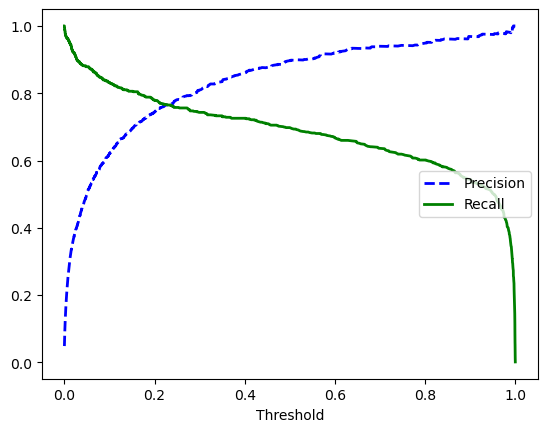

In [518]:
plt.plot(thresholds, precisions[:-1], "b--", label="Precision", linewidth=2)
plt.plot(thresholds, recalls[:-1], "g-", label="Recall", linewidth=2)
plt.xlabel("Threshold")
plt.legend(loc="center right");

## finding the best mathmatical threshold (highest f1 score)

In [521]:
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)

In [523]:
optimal_f1_idx = np.argmax(f1_scores)
best_f1_threshold = thresholds[optimal_f1_idx]
best_f1_threshold

0.4100794

In [525]:
f1_scores[optimal_f1_idx] , precisions[optimal_f1_idx] , recalls[optimal_f1_idx]

(0.7898089167015712, 0.8686514886164624, 0.724087591240876)

In [527]:
from custom_transformers import ThresholdWrapper
from sklearn.metrics import ConfusionMatrixDisplay

In [529]:
best_f1_score_model = ThresholdWrapper(pipeline= model , threshold=0.4)

## best auto banner threshold (high precision)

In [532]:
precision_95_idx = np.argmax(precisions >=0.95)
precision_95_threshold = thresholds[precision_95_idx]
precision_95_threshold

0.80400676

In [534]:
recalls[precision_95_idx] 

0.6

In [536]:
auto_banner_model = ThresholdWrapper(pipeline= model , threshold=0.8)

## best threshold for initial filtering (high recall)

In [539]:
recall_80_idx = np.argmax(recalls <=0.8)
recall_80_threshold = thresholds[recall_80_idx]
recall_80_threshold

0.1634706

In [541]:
precisions[recall_80_idx]

0.7116883116883117

In [543]:
initial_filtering_model = ThresholdWrapper(pipeline= model , threshold=0.17)

# Test set

In [556]:
from sklearn.metrics import (
    precision_score, 
    recall_score, 
    f1_score, 
)

In [560]:
# best f1 score model

best_f1_score_pred = best_f1_score_model.predict(X_test)


best_f1_precision = precision_score(Y_test, best_f1_score_pred)
best_f1_recall = recall_score(Y_test, best_f1_score_pred)
best_f1_f1 = f1_score(Y_test, best_f1_score_pred)

best_f1_precision ,best_f1_recall ,best_f1_f1

(0.8819444444444444, 0.7426900584795322, 0.8063492063492064)

In [562]:
# auto banner 

auto_banner_pred = auto_banner_model.predict(X_test)

auto_banner_precision = precision_score(Y_test, auto_banner_pred)
auto_banner_recall = recall_score(Y_test, auto_banner_pred)
auto_banner_f1 = f1_score(Y_test, auto_banner_pred)

auto_banner_precision ,auto_banner_recall , auto_banner_f1

(0.9809523809523809, 0.6023391812865497, 0.7463768115942029)

In [564]:
# initial filter

init_filter_pred = initial_filtering_model.predict(X_test)

init_filter_precision = precision_score(Y_test, init_filter_pred)
init_filter_recall = recall_score(Y_test, init_filter_pred)
init_filter_f1 = f1_score(Y_test, init_filter_pred)

init_filter_precision , init_filter_recall , init_filter_f1

(0.6893203883495146, 0.8304093567251462, 0.753315649867374)

In [9]:
import joblib
import platform
import sklearn
import xgboost
import pandas
import numpy
import scipy
# ==========================================
# 2. Generate Strict requirements.txt
# ==========================================
req_filename = 'requirements.txt'

with open(req_filename, 'w') as f:
    f.write("# ==========================================\n")
    f.write(f"# Python Version Required: {platform.python_version()}\n")
    f.write("# (Ensure your server runs this exact minor version, e.g., 3.10.x)\n")
    f.write("# ==========================================\n\n")
    
    # Write the exact versions currently running in your RAM
    f.write(f"scikit-learn=={sklearn.__version__}\n")
    f.write(f"xgboost=={xgboost.__version__}\n")
    f.write(f"pandas=={pandas.__version__}\n")
    f.write(f"numpy=={numpy.__version__}\n")
    f.write(f"scipy=={scipy.__version__}\n")
    
    # Joblib is required to load the model back up
    f.write(f"joblib=={joblib.__version__}\n")